<a href="https://colab.research.google.com/github/joluva/datascience/blob/main/Pr%C3%A1ctica_de_An%C3%A1lisis_y_Visualizaci%C3%B3n_de_Datos_con_Python_MODULO_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importar el dataset

In [ ]:
# Importamos las librerías Pandas y Numpy
import pandas as pd
import numpy as np
# Importamos los paquetes que vamos a usar y definimos la ruta en la que vamos a trabajar
import matplotlib.pyplot as plt, seaborn as sns
# importamos algunos paquetes adicionales para trabajar con fechas
import datetime
import os
# usamos esta opción para que muestre los graficos en la celda de output
%matplotlib inline

# Importar el conjunto de datos de ventas
df_ventas = pd.read_csv('dataset_practica.csv')
# Asegúrate de reemplazar 'dataset_practica.csv' con el nombre real de tu archivo


# Importar el dataset de datos extra
df_datos_extra = pd.read_csv('datos extra.csv')
# Asegúrate de reemplazar 'datos_extra.csv' con el nombre real de tu archivo


# Importar el dataset de información de productos
df_info_productos = pd.read_csv('Info_Productos.csv')
# Asegúrate de reemplazar 'Info_Productos.csv' con el nombre real de tu archivo



# 1. Chequeos básicos

## Chequeos básicos para el dataset de ventas

In [ ]:
print("Chequeos básicos para el dataset de ventas:")
print("Número de filas y columnas:", df_ventas.shape)
print("\nPrimeras filas del dataset:")
print(df_ventas.head())
print("\nTipos de datos de cada columna:")
print(df_ventas.dtypes)
print("\nValores faltantes por columna:")
print(df_ventas.isnull().sum())

Chequeos básicos para el dataset de ventas:
Número de filas y columnas: (96, 6)

Primeras filas del dataset:
        Fecha    Tienda    Producto  Cantidad  Venta_Unitaria Region
0  2024-01-01  Tienda_A  Producto_1        10               9  Norte
1  2024-01-01  Tienda_A  Producto_2        20               6  Norte
2  2024-01-01  Tienda_B  Producto_1        15              11    Sur
3  2024-01-01  Tienda_B  Producto_2        25               7    Sur
4  2024-01-02  Tienda_A  Producto_1        12              11  Norte

Tipos de datos de cada columna:
Fecha             object
Tienda            object
Producto          object
Cantidad           int64
Venta_Unitaria     int64
Region            object
dtype: object

Valores faltantes por columna:
Fecha             0
Tienda            1
Producto          0
Cantidad          0
Venta_Unitaria    0
Region            0
dtype: int64


## Chequeos básicos para el dataset de datos extra

In [ ]:
print("\nChequeos básicos para el dataset de datos extra:")
print("Número de filas y columnas:", df_datos_extra.shape)
print("\nPrimeras filas del dataset:")
print(df_datos_extra.head())
print("\nTipos de datos de cada columna:")
print(df_datos_extra.dtypes)
print("\nValores faltantes por columna:")
print(df_datos_extra.isnull().sum())


Chequeos básicos para el dataset de datos extra:
Número de filas y columnas: (48, 6)

Primeras filas del dataset:
        Fecha    Tienda    Producto  Cantidad  Venta_Unitaria Region
0  2024-01-01  Tienda_A  Producto_3        10               5  Norte
1  2024-01-01  Tienda_A  Producto_4        20               8  Norte
2  2024-01-01  Tienda_B  Producto_3        15               5    Sur
3  2024-01-01  Tienda_B  Producto_4        25               8    Sur
4  2024-01-02  Tienda_A  Producto_3        12               5  Norte

Tipos de datos de cada columna:
Fecha             object
Tienda            object
Producto          object
Cantidad           int64
Venta_Unitaria     int64
Region            object
dtype: object

Valores faltantes por columna:
Fecha             0
Tienda            0
Producto          0
Cantidad          0
Venta_Unitaria    0
Region            0
dtype: int64


## Chequeos básicos para el dataset de información de productos

In [ ]:
print("\nChequeos básicos para el dataset de información de productos:")
print("Número de filas y columnas:", df_info_productos.shape)
print("\nPrimeras filas del dataset:")
print(df_info_productos.head())
print("\nTipos de datos de cada columna:")
print(df_info_productos.dtypes)
print("\nValores faltantes por columna:")
print(df_info_productos.isnull().sum())


Chequeos básicos para el dataset de información de productos:
Número de filas y columnas: (4, 15)

Primeras filas del dataset:
     Producto    Fabricante  Peso   Dimensiones Fecha_Fabricacion  \
0  Producto_1  Fabricante_A  500g    10x10x5 cm        2023-12-01   
1  Producto_2  Fabricante_B  750g    12x12x6 cm        2023-11-01   
2  Producto_3  Fabricante_C  600g  11x11x5.5 cm        2023-10-01   
3  Producto_4  Fabricante_D  700g    15x15x7 cm        2023-09-01   

  Fecha_Vencimiento               Tipo_Pago    Vendedor  \
0        2024-12-01      Tarjeta de crédito  Vendedor_1   
1        2024-11-01                Efectivo  Vendedor_2   
2        2024-10-01  Transferencia bancaria  Vendedor_3   
3        2024-09-01      Tarjeta de crédito  Vendedor_1   

          Tipo_Descuento  Temperatura  Humedad  Precipitacion  IPC  \
0  Descuento por volumen           25       60            0.1  150   
1          Sin descuento           28       55            0.0  155   
2  Descuento por lea

# 2. Filtros de columnas y filas, integración de datos

In [ ]:
# Filtrar columnas relevantes para el análisis
columnas_relevantes = ['Fecha', 'Tienda', 'Producto', 'Cantidad', 'Venta_Unitaria', 'Region']
df_ventas_filtrado = df_ventas[columnas_relevantes]

# Aplicar un filtro para seleccionar solo los datos de las tiendas ubicadas en una región específica (por ejemplo, Norte)
region_especifica = 'Norte'
df_ventas_region_especifica = df_ventas_filtrado[df_ventas_filtrado['Region'] == region_especifica]

# Concatenar los conjuntos de datos verticalmente
df_concatenado = pd.concat([df_ventas, df_datos_extra], ignore_index=True)

# Mostrar el resultado
print(df_concatenado.head())

# Unir el resultado de la concatenación con la base de datos de información de productos
df_final = pd.merge(df_concatenado, df_info_productos, on='Producto', how='left')

# Mostrar el resultado final
print(df_final.head())

        Fecha    Tienda    Producto  Cantidad  Venta_Unitaria Region
0  2024-01-01  Tienda_A  Producto_1        10               9  Norte
1  2024-01-01  Tienda_A  Producto_2        20               6  Norte
2  2024-01-01  Tienda_B  Producto_1        15              11    Sur
3  2024-01-01  Tienda_B  Producto_2        25               7    Sur
4  2024-01-02  Tienda_A  Producto_1        12              11  Norte
        Fecha    Tienda    Producto  Cantidad  Venta_Unitaria Region  \
0  2024-01-01  Tienda_A  Producto_1        10               9  Norte   
1  2024-01-01  Tienda_A  Producto_2        20               6  Norte   
2  2024-01-01  Tienda_B  Producto_1        15              11    Sur   
3  2024-01-01  Tienda_B  Producto_2        25               7    Sur   
4  2024-01-02  Tienda_A  Producto_1        12              11  Norte   

     Fabricante  Peso Dimensiones Fecha_Fabricacion Fecha_Vencimiento  \
0  Fabricante_A  500g  10x10x5 cm        2023-12-01        2024-12-01   
1  Fabr

# 3. Agregaciones

In [ ]:
# Convertir la columna 'Fecha' a tipo datetime para poder extraer el mes
df_final['Fecha'] = pd.to_datetime(df_final['Fecha'])

# Calcular las ventas totales por producto para cada mes
ventas_por_mes = df_final.groupby([df_final['Fecha'].dt.month, 'Producto'])['Cantidad'].sum()
print("Ventas totales por producto para cada mes:")
print(ventas_por_mes)


# Calcular el promedio de ventas diarias para cada tienda
ventas_promedio_por_tienda = df_final.groupby('Tienda')['Cantidad'].mean()
print("\nPromedio de ventas diarias para cada tienda:")
print(ventas_promedio_por_tienda)

# Determinar la cantidad total de productos vendidos en cada región
productos_vendidos_por_region = df_final.groupby('Region')['Cantidad'].sum()
print("\nCantidad total de productos vendidos en cada región:")
print(productos_vendidos_por_region)

Ventas totales por producto para cada mes:
Fecha  Producto  
1      Producto_1     321
       Producto_2     542
       Producto_3     642
       Producto_4    1084
Name: Cantidad, dtype: int64

Promedio de ventas diarias para cada tienda:
Tienda
Tienda_A    15.394366
Tienda_B    20.500000
Name: Cantidad, dtype: float64

Cantidad total de productos vendidos en cada región:
Region
Norte    1093
Sur      1496
Name: Cantidad, dtype: int64


In [ ]:
# Calcular las ventas totales por producto para cada mes
# Genera la variable del mes
df_final['Fecha'] = pd.to_datetime(df_final['Fecha'],format="%Y-%d-%m")
#df_final['Fecha'] = df_final['Fecha'].strftime("%Y-%m-%d")
df_final['mes'] = df_final['Fecha'].dt.month
#ventas_por_mes=df_final.groupby(["mes"], as_index=False).agg({"Cantidad": "sum"})
#ventas_por_mes = df_final.groupby([df_final['Fecha'].dt.month, 'Producto'])['Cantidad'].sum()
#ventas_por_mes
df_final

,Fecha,Tienda,Producto,Cantidad,Venta_Unitaria,Region,Fabricante,Peso,Dimensiones,Fecha_Fabricacion,...,Tipo_Pago,Vendedor,Tipo_Descuento,Temperatura,Humedad,Precipitacion,IPC,Confianza_Consumidor,Tipo_Cambio,mes
0,2024-01-01,Tienda_A,Producto_1,10,9,Norte,Fabricante_A,500g,10x10x5 cm,2023-12-01,...,Tarjeta de crédito,Vendedor_1,Descuento por volumen,25,60,0.1,150,70,20.5,1
1,2024-01-01,Tienda_A,Producto_2,20,6,Norte,Fabricante_B,750g,12x12x6 cm,2023-11-01,...,Efectivo,Vendedor_2,Sin descuento,28,55,0.0,155,65,21.0,1
2,2024-01-01,Tienda_B,Producto_1,15,11,Sur,Fabricante_A,500g,10x10x5 cm,2023-12-01,...,Tarjeta de crédito,Vendedor_1,Descuento por volumen,25,60,0.1,150,70,20.5,1
3,2024-01-01,Tienda_B,Producto_2,25,7,Sur,Fabricante_B,750g,12x12x6 cm,2023-11-01,...,Efectivo,Vendedor_2,Sin descuento,28,55,0.0,155,65,21.0,1
4,2024-01-02,Tienda_A,Producto_1,12,11,Norte,Fabricante_A,500g,10x10x5 cm,2023-12-01,...,Tarjeta de crédito,Vendedor_1,Descuento por volumen,25,60,0.1,150,70,20.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2024-01-11,Tienda_B,Producto_4,25,8,Sur,Fabricante_D,700g,15x15x7 cm,2023-09-01,...,Tarjeta de crédito,Vendedor_1,Sin descuento,26,65,0.3,160,68,19.8,1
140,2024-01-12,Tienda_A,Producto_3,12,5,Norte,Fabricante_C,600g,11x11x5.5 cm,2023-10-01,...,Transferencia bancaria,Vendedor_3,Descuento por lealtad,23,70,0.2,145,75,20.0,1
141,2024-01-12,Tienda_A,Producto_4,22,8,Norte,Fabricante_D,700g,15x15x7 cm,2023-09-01,...,Tarjeta de crédito,Vendedor_1,Sin descuento,26,65,0.3,160,68,19.8,1
142,2024-01-12,Tienda_B,Producto_3,18,5,Sur,Fabricante_C,600g,11x11x5.5 cm,2023-10-01,...,Transferencia bancaria,Vendedor_3,Descuento por lealtad,23,70,0.2,145,75,20.0,1


# 4. Chequeos básicos de calidad

## Verificar la consistencia de los datos

In [ ]:
# Verificar valores negativos para cantidades vendidas
cantidades_negativas = df_final[df_final['Cantidad'] < 0]
if not cantidades_negativas.empty:
    print("Se encontraron valores negativos para cantidades vendidas:")
    print(cantidades_negativas)
else:
    print("No se encontraron valores negativos para cantidades vendidas.")

# Verificar valores negativos para precios
precios_negativos = df_final[df_final['Venta_Unitaria'] < 0]
if not precios_negativos.empty:
    print("\nSe encontraron valores negativos para precios:")
    print(precios_negativos)
else:
    print("\nNo se encontraron valores negativos para precios.")

No se encontraron valores negativos para cantidades vendidas.

No se encontraron valores negativos para precios.


## Examinar la distribución de los datos

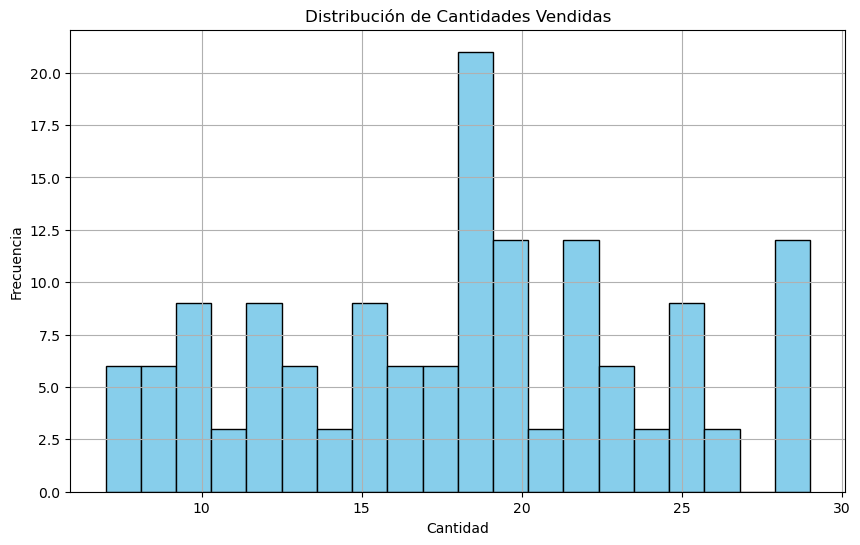

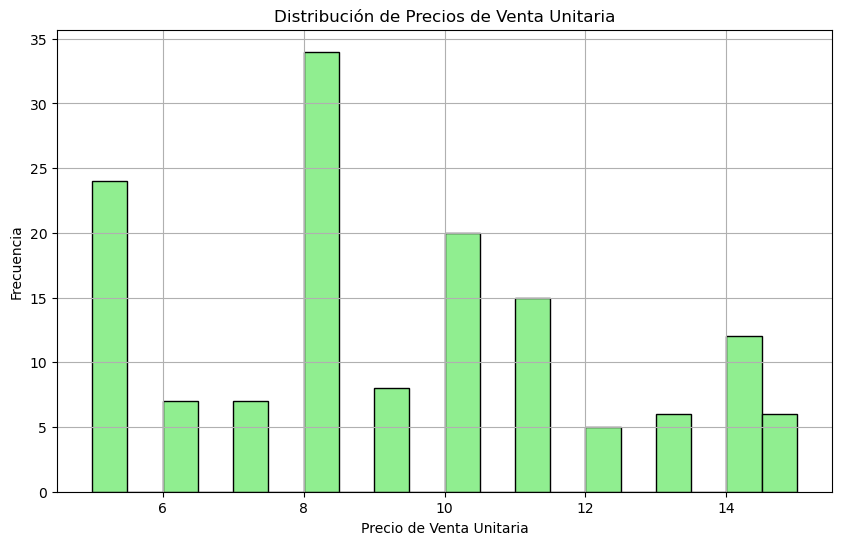

In [ ]:
# Histograma de cantidades vendidas
plt.figure(figsize=(10, 6))
plt.hist(df_final['Cantidad'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de Cantidades Vendidas')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# Histograma de precios de venta unitaria
plt.figure(figsize=(10, 6))
plt.hist(df_final['Venta_Unitaria'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribución de Precios de Venta Unitaria')
plt.xlabel('Precio de Venta Unitaria')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# 5. Valores faltantes e inconsistencias

<Axes: >

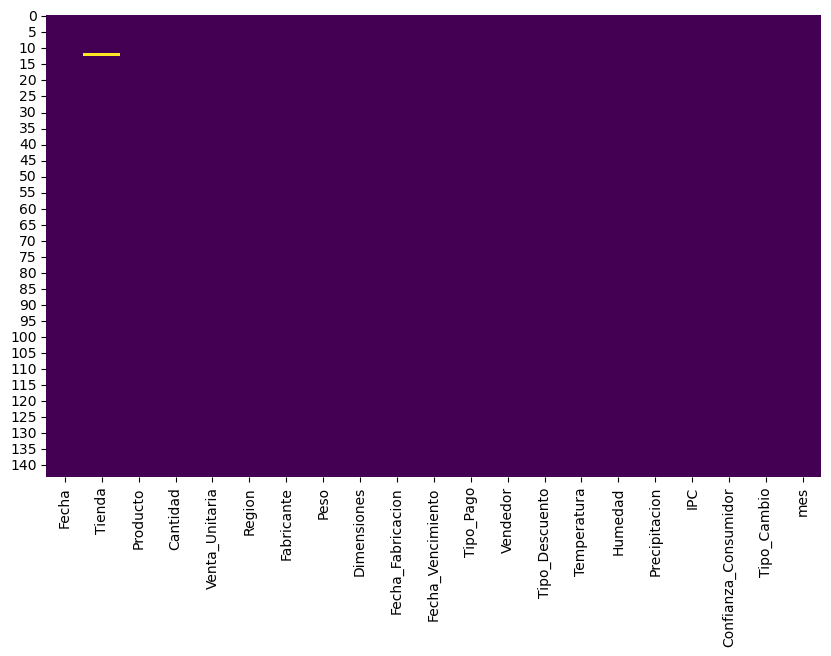

In [ ]:
# Detecto la cantidad de datos faltantes

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df_final.isnull(), cbar=False,cmap='viridis')

In [ ]:
print("Filas con valores faltantes:")
print(df_final[df_final.isnull().any(axis=1)])

Filas con valores faltantes:
        Fecha Tienda    Producto  Cantidad  Venta_Unitaria Region  \
12 2024-01-04    NaN  Producto_1        20              10    Sur   

      Fabricante  Peso Dimensiones Fecha_Fabricacion  ...           Tipo_Pago  \
12  Fabricante_A  500g  10x10x5 cm        2023-12-01  ...  Tarjeta de crédito   

      Vendedor         Tipo_Descuento Temperatura  Humedad  Precipitacion  \
12  Vendedor_1  Descuento por volumen          25       60            0.1   

    IPC  Confianza_Consumidor  Tipo_Cambio  mes  
12  150                    70         20.5    1  

[1 rows x 21 columns]


Podriamos resolver los valores faltantes utilizando dos opciones: eliminando la fila que contiene valores faltantes o reemplazando el valor faltante con el promedio de los datos de la columna.

In [ ]:
# Opción 1: Eliminar filas con valores faltantes
df_sin_faltantes = df_final.dropna()

# Opción 2: Reemplazar valores faltantes con el promedio de la columna
promedio_cantidad = df_final['Cantidad'].mean()
df_con_promedio = df_final.fillna({'Cantidad': promedio_cantidad})

En la primera opción, eliminamos todas las filas que contienen al menos un valor faltante utilizando el método dropna(). Esto puede ser una opción viable si la cantidad de filas con valores faltantes es pequeña en comparación con el tamaño total del dataset y si eliminar estas filas no afecta significativamente el análisis.

En la segunda opción, reemplazamos los valores faltantes en la columna 'Cantidad' con el promedio de todos los valores no faltantes en esa columna utilizando el método fillna(). Esta opción puede ser útil si queremos mantener todas las filas en el dataset y no queremos perder información, pero también debemos considerar que puede introducir sesgo si hay una gran cantidad de valores faltantes.

Es importante evaluar cuidadosamente estas opciones y considerar el impacto en el análisis antes de tomar una decisión.

# 6. Valores atípicos/extremos

## Aquí podrías utilizar técnicas estadísticas para detectar valores atípicos en 'Cantidad' o 'Venta_Unitaria'

Para detectar valores atípicos en el conjunto de datos, podemos utilizar técnicas estadísticas como el percentil 99. Luego, podemos considerar dos opciones para tratar estos valores atípicos: eliminarlos o transformarlos.


In [ ]:
# Identificar valores atípicos
# Percentil 99 de los valores del tipo de cambio
p99_cantidad = np.percentile(df_final['Cantidad'], 99)
p99_cantidad

29.0

In [ ]:
# Vemos las observaciones por encima del percentil 99
df_final[df_final['Cantidad'] >= p99_cantidad]

,Fecha,Tienda,Producto,Cantidad,Venta_Unitaria,Region,Fabricante,Peso,Dimensiones,Fecha_Fabricacion,...,Tipo_Pago,Vendedor,Tipo_Descuento,Temperatura,Humedad,Precipitacion,IPC,Confianza_Consumidor,Tipo_Cambio,mes
23,2024-01-06,Tienda_B,Producto_2,29,8,Sur,Fabricante_B,750g,12x12x6 cm,2023-11-01,...,Efectivo,Vendedor_2,Sin descuento,28,55,0.0,155,65,21.0,1
71,2024-01-06,Tienda_B,Producto_4,29,11,Sur,Fabricante_D,700g,15x15x7 cm,2023-09-01,...,Tarjeta de crédito,Vendedor_1,Sin descuento,26,65,0.3,160,68,19.8,1
119,2024-01-06,Tienda_B,Producto_4,29,8,Sur,Fabricante_D,700g,15x15x7 cm,2023-09-01,...,Tarjeta de crédito,Vendedor_1,Sin descuento,26,65,0.3,160,68,19.8,1


In [ ]:
# Opción 1: Eliminar valores atípicos
df_sin_atipicos = df_final[df_final['Cantidad'] <= p99_cantidad]

# Opción 2: Transformar valores atípicos
df_transformado = df_final.copy()
df_transformado['Cantidad'] = df_transformado['Cantidad'].apply(lambda x: p99_cantidad if x > p99_cantidad else x)


En este código, primero calculamos el valor del percentil 99 y luego calculamos los valores atípicos que caen fuera de este límite.

Para solucionar los valores atípicos, proporcioné dos opciones:

Eliminarlos: Creamos un nuevo DataFrame que excluya las filas que contienen valores atípicos.

Transformarlos: Creamos una copia del DataFrame original y reemplazamos los valores atípicos por los valores del primer y tercer cuartil, respectivamente.

Puedes elegir la opción que mejor se adapte a tus necesidades y al contexto de tu análisis.

In [ ]:
df_final

,Fecha,Tienda,Producto,Cantidad,Venta_Unitaria,Region,Fabricante,Peso,Dimensiones,Fecha_Fabricacion,...,Tipo_Pago,Vendedor,Tipo_Descuento,Temperatura,Humedad,Precipitacion,IPC,Confianza_Consumidor,Tipo_Cambio,mes
0,2024-01-01,Tienda_A,Producto_1,10,9,Norte,Fabricante_A,500g,10x10x5 cm,2023-12-01,...,Tarjeta de crédito,Vendedor_1,Descuento por volumen,25,60,0.1,150,70,20.5,1
1,2024-01-01,Tienda_A,Producto_2,20,6,Norte,Fabricante_B,750g,12x12x6 cm,2023-11-01,...,Efectivo,Vendedor_2,Sin descuento,28,55,0.0,155,65,21.0,1
2,2024-01-01,Tienda_B,Producto_1,15,11,Sur,Fabricante_A,500g,10x10x5 cm,2023-12-01,...,Tarjeta de crédito,Vendedor_1,Descuento por volumen,25,60,0.1,150,70,20.5,1
3,2024-01-01,Tienda_B,Producto_2,25,7,Sur,Fabricante_B,750g,12x12x6 cm,2023-11-01,...,Efectivo,Vendedor_2,Sin descuento,28,55,0.0,155,65,21.0,1
4,2024-01-02,Tienda_A,Producto_1,12,11,Norte,Fabricante_A,500g,10x10x5 cm,2023-12-01,...,Tarjeta de crédito,Vendedor_1,Descuento por volumen,25,60,0.1,150,70,20.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2024-01-11,Tienda_B,Producto_4,25,8,Sur,Fabricante_D,700g,15x15x7 cm,2023-09-01,...,Tarjeta de crédito,Vendedor_1,Sin descuento,26,65,0.3,160,68,19.8,1
140,2024-01-12,Tienda_A,Producto_3,12,5,Norte,Fabricante_C,600g,11x11x5.5 cm,2023-10-01,...,Transferencia bancaria,Vendedor_3,Descuento por lealtad,23,70,0.2,145,75,20.0,1
141,2024-01-12,Tienda_A,Producto_4,22,8,Norte,Fabricante_D,700g,15x15x7 cm,2023-09-01,...,Tarjeta de crédito,Vendedor_1,Sin descuento,26,65,0.3,160,68,19.8,1
142,2024-01-12,Tienda_B,Producto_3,18,5,Sur,Fabricante_C,600g,11x11x5.5 cm,2023-10-01,...,Transferencia bancaria,Vendedor_3,Descuento por lealtad,23,70,0.2,145,75,20.0,1


# -----------------------------
# Distribución de precios y cantidades
# -----------------------------

C:\Users\seba_\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


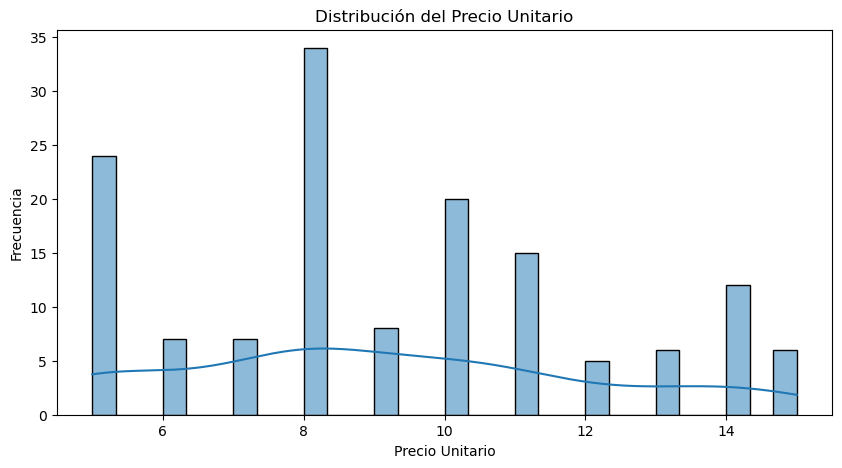

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(df_final["Venta_Unitaria"], bins=30, kde=True)
plt.title("Distribución del Precio Unitario")
plt.xlabel("Precio Unitario")
plt.ylabel("Frecuencia")
plt.show()


C:\Users\seba_\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


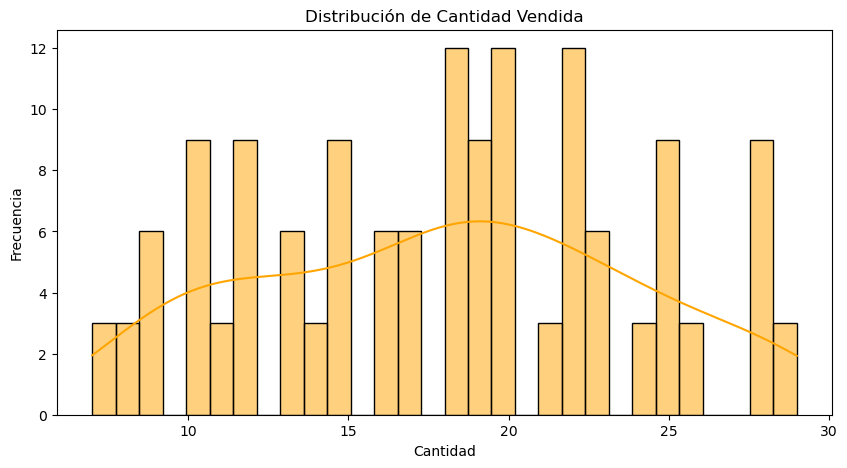

In [ ]:

plt.figure(figsize=(10, 5))
sns.histplot(df_final["Cantidad"], bins=30, kde=True, color='orange')
plt.title("Distribución de Cantidad Vendida")
plt.xlabel("Cantidad")
plt.ylabel("Frecuencia")
plt.show()

# -----------------------------
# Gráfico de dispersión con gráficos marginales
# -----------------------------

C:\Users\seba_\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\seba_\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


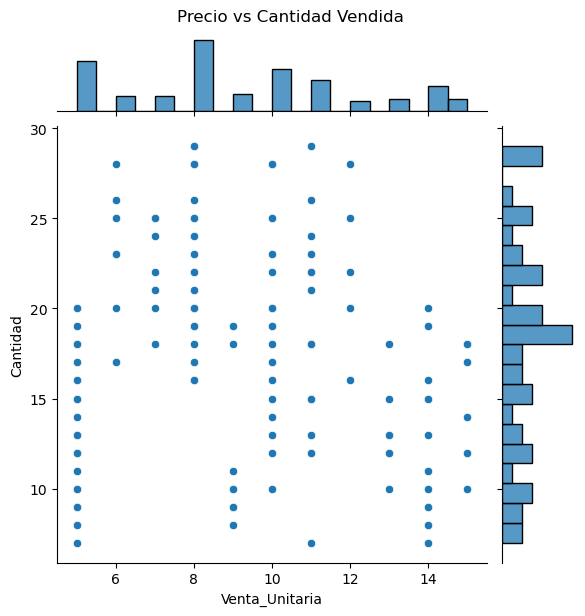

In [ ]:

sns.jointplot(data=df_final, x="Venta_Unitaria", y="Cantidad", kind="scatter", marginal_kws=dict(bins=20))
plt.suptitle("Precio vs Cantidad Vendida", y=1.02)
plt.show()

In [ ]:
df_Tienda_A = df_final[df_final["Tienda"] == "Tienda_A"]
df_Tienda_A

,Fecha,Tienda,Producto,Cantidad,Venta_Unitaria,Region,Fabricante,Peso,Dimensiones,Fecha_Fabricacion,...,Tipo_Pago,Vendedor,Tipo_Descuento,Temperatura,Humedad,Precipitacion,IPC,Confianza_Consumidor,Tipo_Cambio,mes
0,2024-01-01,Tienda_A,Producto_1,10,9,Norte,Fabricante_A,500g,10x10x5 cm,2023-12-01,...,Tarjeta de crédito,Vendedor_1,Descuento por volumen,25,60,0.1,150,70,20.5,1
1,2024-01-01,Tienda_A,Producto_2,20,6,Norte,Fabricante_B,750g,12x12x6 cm,2023-11-01,...,Efectivo,Vendedor_2,Sin descuento,28,55,0.0,155,65,21.0,1
4,2024-01-02,Tienda_A,Producto_1,12,11,Norte,Fabricante_A,500g,10x10x5 cm,2023-12-01,...,Tarjeta de crédito,Vendedor_1,Descuento por volumen,25,60,0.1,150,70,20.5,1
5,2024-01-02,Tienda_A,Producto_2,22,8,Norte,Fabricante_B,750g,12x12x6 cm,2023-11-01,...,Efectivo,Vendedor_2,Sin descuento,28,55,0.0,155,65,21.0,1
8,2024-01-03,Tienda_A,Producto_1,9,9,Norte,Fabricante_A,500g,10x10x5 cm,2023-12-01,...,Tarjeta de crédito,Vendedor_1,Descuento por volumen,25,60,0.1,150,70,20.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,2024-01-10,Tienda_A,Producto_4,19,8,Norte,Fabricante_D,700g,15x15x7 cm,2023-09-01,...,Tarjeta de crédito,Vendedor_1,Sin descuento,26,65,0.3,160,68,19.8,1
136,2024-01-11,Tienda_A,Producto_3,10,5,Norte,Fabricante_C,600g,11x11x5.5 cm,2023-10-01,...,Transferencia bancaria,Vendedor_3,Descuento por lealtad,23,70,0.2,145,75,20.0,1
137,2024-01-11,Tienda_A,Producto_4,20,8,Norte,Fabricante_D,700g,15x15x7 cm,2023-09-01,...,Tarjeta de crédito,Vendedor_1,Sin descuento,26,65,0.3,160,68,19.8,1
140,2024-01-12,Tienda_A,Producto_3,12,5,Norte,Fabricante_C,600g,11x11x5.5 cm,2023-10-01,...,Transferencia bancaria,Vendedor_3,Descuento por lealtad,23,70,0.2,145,75,20.0,1


C:\Users\seba_\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\seba_\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


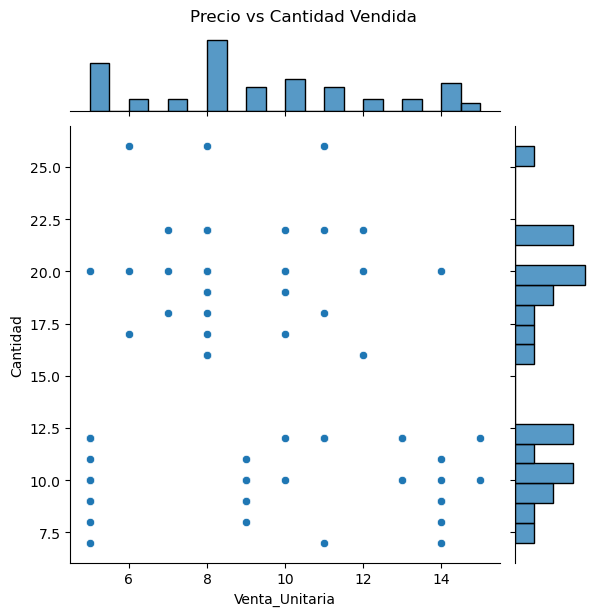

In [ ]:
sns.jointplot(data=df_Tienda_A, x="Venta_Unitaria", y="Cantidad", kind="scatter", marginal_kws=dict(bins=20))
plt.suptitle("Precio vs Cantidad Vendida", y=1.02)
plt.show()

# -----------------------------
# Boxplot por producto
# -----------------------------

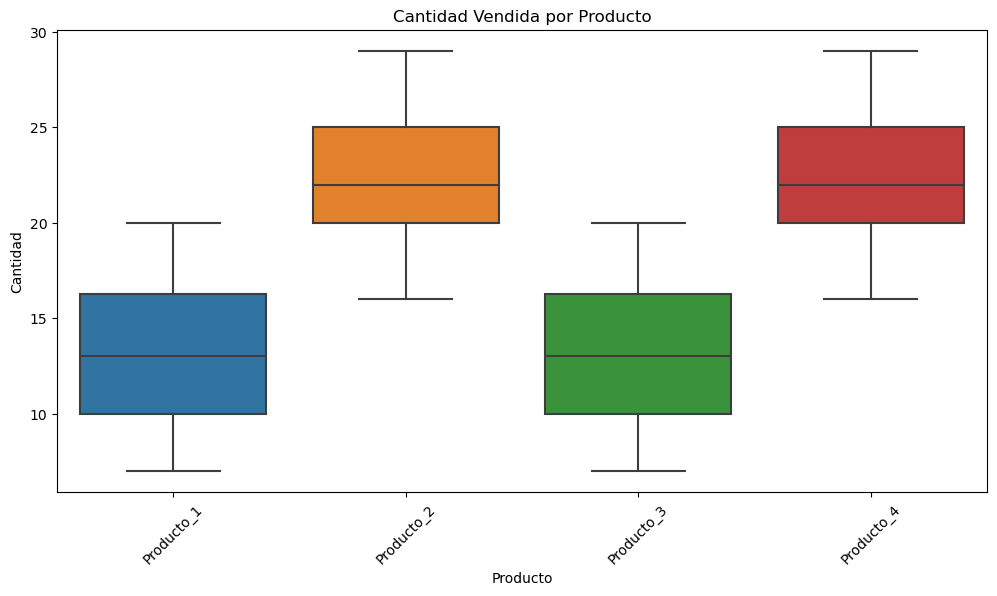

In [ ]:

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_final, x="Producto", y="Cantidad")
plt.title("Cantidad Vendida por Producto")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# Ventas totales por medio de pago
# -----------------------------

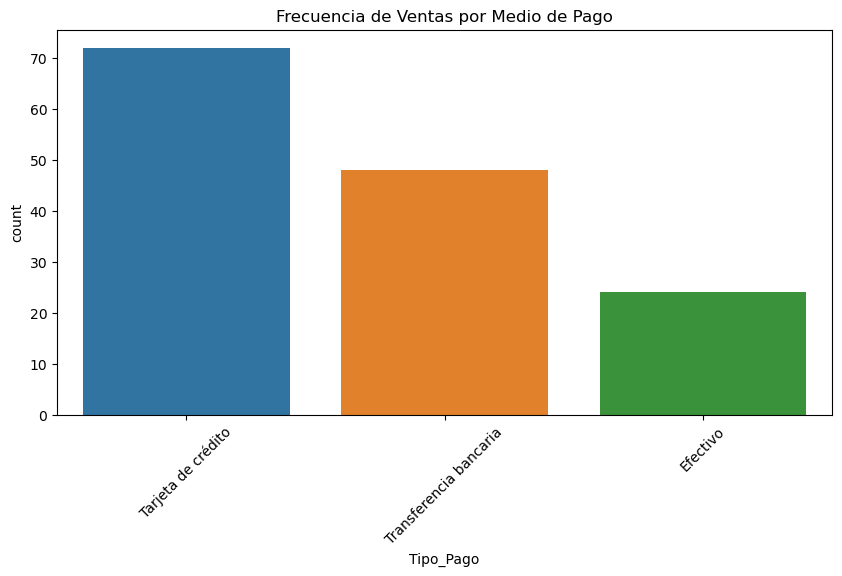

In [ ]:

plt.figure(figsize=(10, 5))
sns.countplot(data=df_final, x="Tipo_Pago", order=df_final["Tipo_Pago"].value_counts().index)
plt.title("Frecuencia de Ventas por Medio de Pago")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# -----------------------------
# Series temporales de ventas
# -----------------------------

In [ ]:
ventas_diarias = df_final.groupby('Fecha')['Cantidad'].sum().reset_index()
ventas_diarias

,Fecha,Cantidad
0,2024-01-01,210
1,2024-01-02,240
2,2024-01-03,192
3,2024-01-04,234
4,2024-01-05,180
5,2024-01-06,255
6,2024-01-07,186
7,2024-01-08,210
8,2024-01-09,240
9,2024-01-10,192


C:\Users\seba_\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\seba_\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


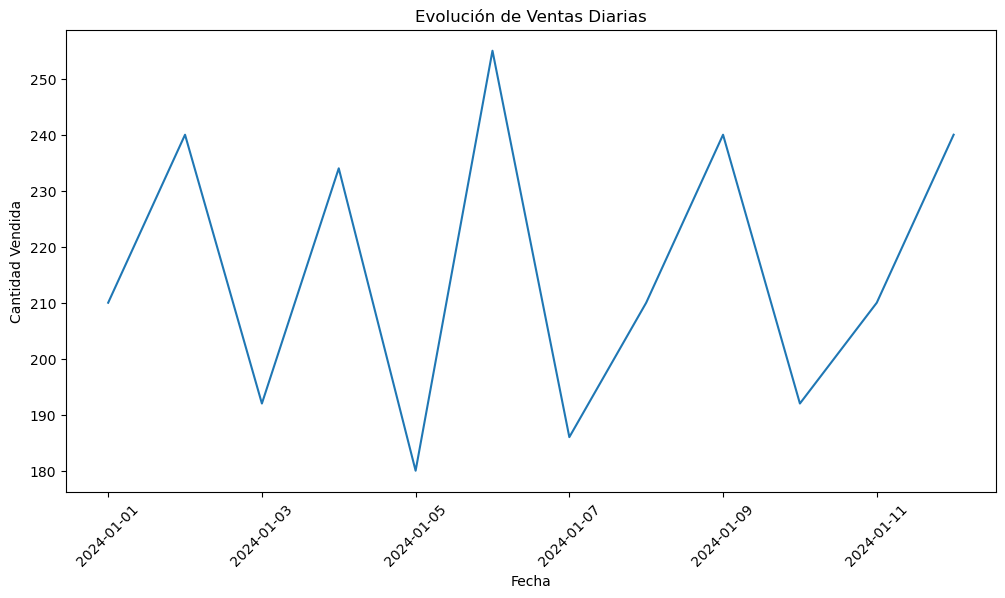

In [ ]:

plt.figure(figsize=(12, 6))
sns.lineplot(data=ventas_diarias, x='Fecha', y='Cantidad')
plt.title("Evolución de Ventas Diarias")
plt.xlabel("Fecha")
plt.ylabel("Cantidad Vendida")
plt.xticks(rotation=45)
plt.show()

# Gráficos adicionales

## Gráfico de barras de ventas por producto
##### Muestra qué productos se venden más en total.

<Axes: xlabel='Producto', ylabel='Cantidad'>

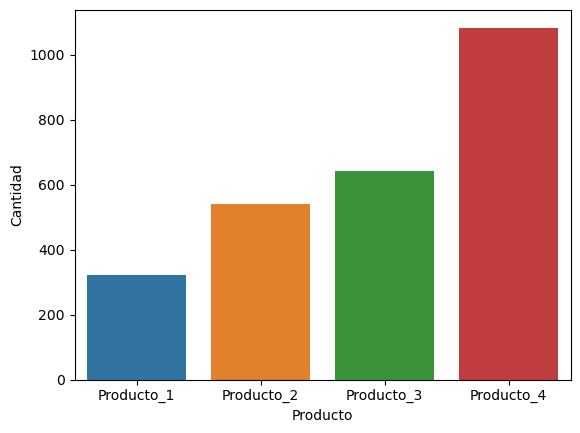

In [ ]:

ventas_totales = df_final.groupby("Producto")["Cantidad"].sum().reset_index()
sns.barplot(data=ventas_totales, x="Producto", y="Cantidad")

## Mapa de calor de ventas por producto y tienda
##### Permite ver de forma rápida qué productos se venden más en qué tienda.

<Axes: xlabel='Tienda', ylabel='Producto'>

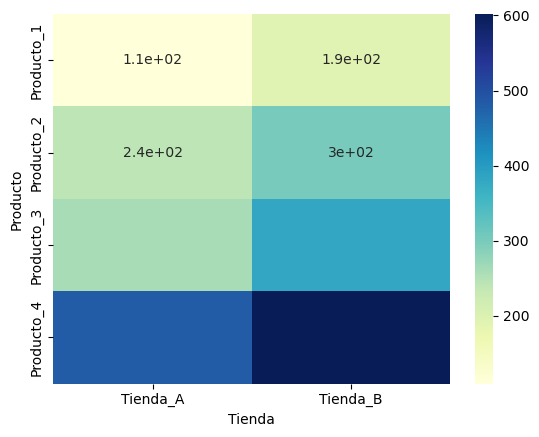

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df_final.isnull(), cbar=False,cmap='viridis')

# Boxplot de precios por producto
##### Para comparar la variabilidad de precios entre productos.

<Axes: xlabel='Producto', ylabel='Venta_Unitaria'>

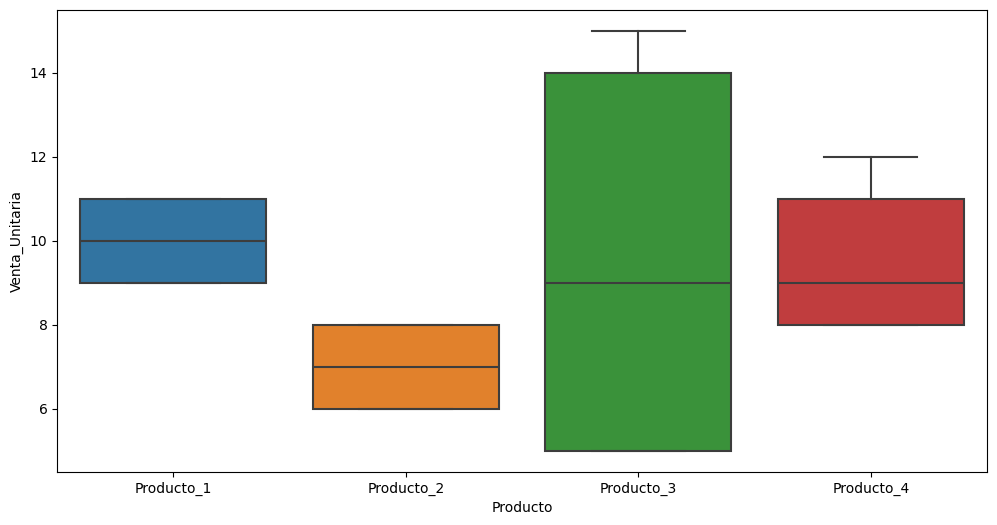

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_final, x="Producto", y="Venta_Unitaria")

# Gráfico de violín (violinplot) por región
##### Similar al boxplot, pero muestra mejor la forma de la distribución.

<Axes: xlabel='Region', ylabel='Cantidad'>

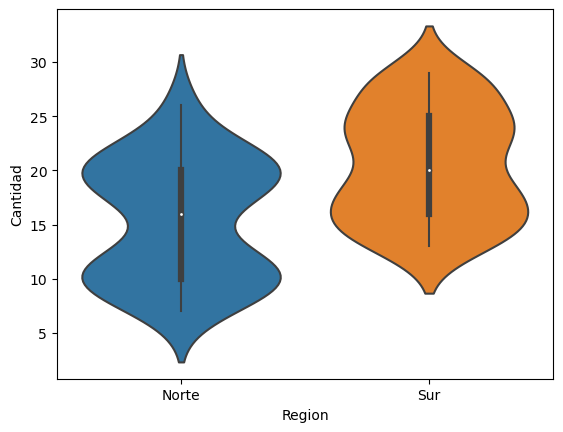

In [ ]:

sns.violinplot(data=df_final, x="Region", y="Cantidad")

# Gráfico de barras de productos por tipo de descuento (usando Info_Productos.csv)
##### Relaciona promociones con ventas.

<Axes: xlabel='Tipo_Descuento', ylabel='count'>

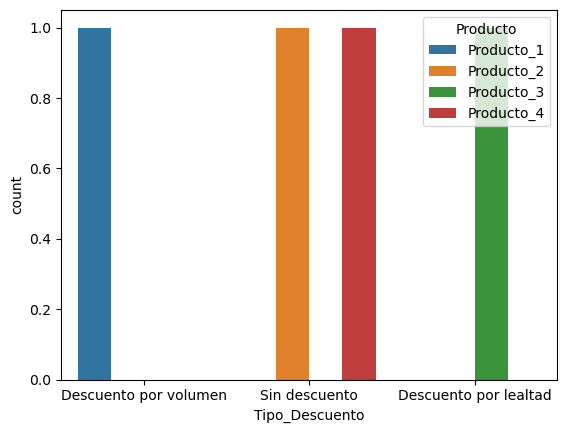

In [ ]:

sns.countplot(data=df_info_productos, x="Tipo_Descuento", hue="Producto")


# Gráfico de dispersión Precio vs Cantidad con color por producto

<Axes: xlabel='Venta_Unitaria', ylabel='Cantidad'>

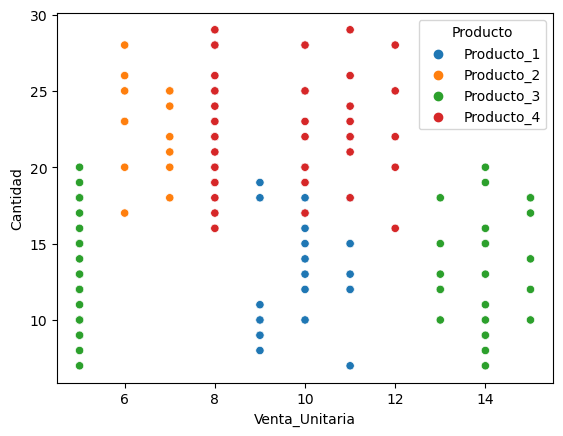

In [ ]:

sns.scatterplot(data=df_final, x="Venta_Unitaria", y="Cantidad", hue="Producto")


# Gráfico de líneas de ventas por tienda

C:\Users\seba_\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\seba_\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Fecha', ylabel='Cantidad'>

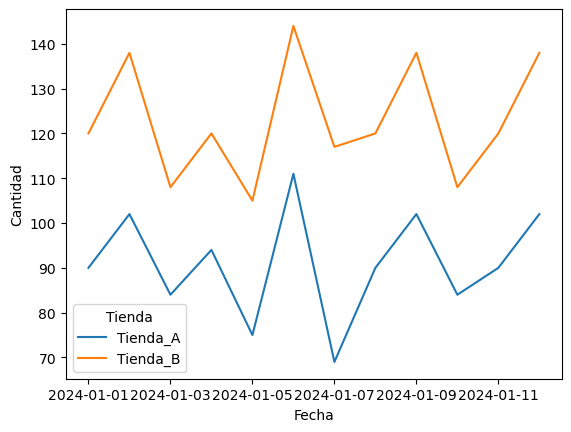

In [ ]:

ventas_fecha_tienda = df_final.groupby(["Fecha", "Tienda"])["Cantidad"].sum().reset_index()
sns.lineplot(data=ventas_fecha_tienda, x="Fecha", y="Cantidad", hue="Tienda")